# Cost & Deployability Analysis

Quantitative cost model for the two-stage Gemini EHS detection pipeline.
All numbers derive from actual Vertex AI token pricing and measured token
counts from `run_logging/experiment_logger.py`.

**Sponsor context:** False positives are acceptable — the system is only
consulted when a real accident is confirmed (staff check whether a report
already exists for that timeframe). This shifts the key metric from
*cost per clip* to **cost per true positive report**.

In [1]:
import os, sys
from pathlib import Path

if "__vsc_ipynb_file__" in dir():
    repo_root = str(Path(__vsc_ipynb_file__).parent.parent)
else:
    def _find_root():
        for p in [Path.cwd()] + list(Path.cwd().parents):
            if (p / "pipeline").is_dir():
                return str(p)
        raise RuntimeError("Could not find repo root.")
    repo_root = _find_root()

os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
pd.set_option('display.float_format', '{:.6f}'.format)
print("cwd:", os.getcwd())

cwd: /home/grom/DevFiles/Classes/Capstone


---
## 1 — Token Cost Model

Token counts and pricing come directly from `run_logging/experiment_logger.py`.
These are consistent across runs — relative comparisons are reliable even if
absolute counts are approximations.

In [2]:
from run_logging.experiment_logger import (
    COST_PER_1K_INPUT_TOKENS,
    COST_PER_1K_OUTPUT_TOKENS,
    _STAGE1_INPUT_TOKENS,
    _STAGE1_OUTPUT_TOKENS,
    _STAGE2_INPUT_TOKENS,
    _STAGE2_OUTPUT_TOKENS,
)

# ── Per-call cost for each model ──────────────────────────────────────────────
MODELS = ["gemini-2.5-flash", "gemini-2.5-flash-lite", "gemini-2.5-pro"]

def stage1_cost_per_call(model: str) -> float:
    """Cost of one Stage 1 binary gate call."""
    return (
        _STAGE1_INPUT_TOKENS  / 1000 * COST_PER_1K_INPUT_TOKENS[model] +
        _STAGE1_OUTPUT_TOKENS / 1000 * COST_PER_1K_OUTPUT_TOKENS[model]
    )

def stage2_cost_per_call(model: str) -> float:
    """Cost of one Stage 2 classification + EHS report call."""
    return (
        _STAGE2_INPUT_TOKENS  / 1000 * COST_PER_1K_INPUT_TOKENS[model] +
        _STAGE2_OUTPUT_TOKENS / 1000 * COST_PER_1K_OUTPUT_TOKENS[model]
    )

def per_clip_cost(
    s1_model: str = "gemini-2.5-flash",
    s2_model: str = "gemini-2.5-flash",
    n_votes: int = 3,
    accident_rate: float = 0.01,
) -> dict:
    """Expected cost per clip given an accident rate."""
    s1 = n_votes * stage1_cost_per_call(s1_model)
    s2 = stage2_cost_per_call(s2_model)
    expected = s1 + accident_rate * s2  # E[cost] = stage1 always + stage2 p(accident)
    return {
        "s1_cost":         round(s1, 8),
        "s2_cost":         round(s2, 8),
        "non_accident":    round(s1, 8),
        "accident_clip":   round(s1 + s2, 8),
        "expected_per_clip": round(expected, 8),
    }

# ── Print token pricing breakdown ─────────────────────────────────────────────
rows = []
for m in MODELS:
    rows.append({
        "Model":           m,
        "S1 input $/1K":  COST_PER_1K_INPUT_TOKENS[m],
        "S1 output $/1K": COST_PER_1K_OUTPUT_TOKENS[m],
        "S1 cost/call":   round(stage1_cost_per_call(m), 8),
        "S2 cost/call":   round(stage2_cost_per_call(m), 8),
        "S1×3 votes":     round(3 * stage1_cost_per_call(m), 8),
    })

df_pricing = pd.DataFrame(rows).set_index("Model")
print(f"Token counts: Stage 1 = {_STAGE1_INPUT_TOKENS} in / {_STAGE1_OUTPUT_TOKENS} out tokens")
print(f"              Stage 2 = {_STAGE2_INPUT_TOKENS} in / {_STAGE2_OUTPUT_TOKENS} out tokens\n")
print(df_pricing.to_string())

Token counts: Stage 1 = 800 in / 30 out tokens
              Stage 2 = 1500 in / 500 out tokens

                       S1 input $/1K  S1 output $/1K  S1 cost/call  S2 cost/call  S1×3 votes
Model                                                                                       
gemini-2.5-flash            0.000075        0.000300      0.000069      0.000262    0.000207
gemini-2.5-flash-lite       0.000037        0.000150      0.000034      0.000131    0.000103
gemini-2.5-pro              0.001250        0.005000      0.001150      0.004375    0.003450


---
## 2 — Accident Rate Sensitivity

How does cost scale with the actual accident rate in the footage?
Stage 1 is always paid; Stage 2 is only paid when Stage 1 fires.

In [3]:
# ── G_005 (recommended config) — Phase 3 measured numbers ─────────────────────
# high_recall Stage 1 + structured Stage 2, n_votes=3, flash/flash
# Confusion matrix from 73 clips (43 accident, 30 non-accident):
#   TP=42  FP=5  TN=25  FN=1
N_ACC_TEST, N_NEG_TEST = 43, 30
TP_TEST, FP_TEST = 42, 5

S1_MODEL      = "gemini-2.5-flash"
S2_MODEL      = "gemini-2.5-flash"
N_VOTES       = 3
BINARY_RECALL = TP_TEST / N_ACC_TEST          # 0.9767
BINARY_PREC   = TP_TEST / (TP_TEST + FP_TEST) # 0.8936
FPR_MEASURED  = FP_TEST / N_NEG_TEST          # 0.1667  ← safety-video negatives (conservative)

S1_PER_CLIP   = N_VOTES * stage1_cost_per_call(S1_MODEL)
S2_PER_CALL   = stage2_cost_per_call(S2_MODEL)

print(f"G_005 measured: recall={BINARY_RECALL:.4f}  precision={BINARY_PREC:.4f}  FPR={FPR_MEASURED:.4f}")
print(f"S1 cost/clip = ${S1_PER_CLIP:.6f}  S2 cost/call = ${S2_PER_CALL:.6f}")
print()
print("NOTE: FPR=16.7% is conservative — measured on challenging safety-video negatives.")
print("Real data centre footage (mundane activity) will have a substantially lower FPR.")
print()

ACCIDENT_RATES = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]
rows = []
for ar in ACCIDENT_RATES:
    n_clips   = 1000
    n_acc     = n_clips * ar
    n_neg     = n_clips * (1 - ar)
    n_tp      = n_acc * BINARY_RECALL
    n_fp      = n_neg * FPR_MEASURED   # measured FPR approach (conservative)
    n_fn      = n_acc * (1 - BINARY_RECALL)
    n_s2      = n_tp + n_fp

    total     = n_clips * S1_PER_CLIP + n_s2 * S2_PER_CALL
    cost_tp   = total / n_tp if n_tp > 0 else float("inf")
    s1_share  = n_clips * S1_PER_CLIP / total * 100

    rows.append({
        "Accident rate":          f"{ar:.1%}",
        "TP / 1K clips":          round(n_tp, 2),
        "FN missed":              round(n_fn, 2),
        "S2 calls (TP+FP)":       round(n_s2, 1),
        "Total cost / 1K ($)":    round(total, 4),
        "Cost per TP report ($)": round(cost_tp, 4),
        "Stage 1 share":          f"{s1_share:.0f}%",
    })

df_sens = pd.DataFrame(rows).set_index("Accident rate")
pd.set_option("display.float_format", "{:.4f}".format)
print("Sensitivity Table — G_005 Flash/Flash (n_votes=3), per 1,000 clips")
print("FP modelled via measured FPR=16.7% (conservative upper bound)\n")
display(df_sens)

G_005 measured: recall=0.9767  precision=0.8936  FPR=0.1667
S1 cost/clip = $0.000207  S2 cost/call = $0.000262

NOTE: FPR=16.7% is conservative — measured on challenging safety-video negatives.
Real data centre footage (mundane activity) will have a substantially lower FPR.

Sensitivity Table — G_005 Flash/Flash (n_votes=3), per 1,000 clips
FP modelled via measured FPR=16.7% (conservative upper bound)



,TP / 1K clips,FN missed,S2 calls (TP+FP),Total cost / 1K ($),Cost per TP report ($),Stage 1 share
Accident rate,,,,,,
0.1%,0.9800,0.0200,167.5000,0.2510,0.2569,82%
0.5%,4.8800,0.1200,170.7000,0.2518,0.0516,82%
1.0%,9.7700,0.2300,174.8000,0.2529,0.0259,82%
2.0%,19.5300,0.4700,182.9000,0.2550,0.0131,81%
5.0%,48.8400,1.1600,207.2000,0.2614,0.0054,79%
10.0%,97.6700,2.3300,247.7000,0.2720,0.0028,76%


---
## 3 — Sponsor Context: FP Economics

The sponsor confirmed false positives are acceptable because the system is
only accessed when a real accident is confirmed — staff check whether a report
was auto-generated in that timeframe. An unused EHS report costs Stage 2 API
fees but causes no operational harm. False **negatives** are the real loss:
no report is generated when an accident occurred.

In [4]:
# ── G_005 at two deployment scenarios ─────────────────────────────────────────
for AR, label in [(0.001, "data centre (0.1%)"), (0.01, "industrial site (1%)")]:
    N = 1000
    n_acc = N * AR
    n_neg = N * (1 - AR)
    n_tp  = n_acc * BINARY_RECALL
    n_fp  = n_neg * FPR_MEASURED
    n_fn  = n_acc * (1 - BINARY_RECALL)
    n_s2  = n_tp + n_fp

    total     = N * S1_PER_CLIP + n_s2 * S2_PER_CALL
    cost_tp   = total / n_tp if n_tp > 0 else float("inf")
    fp_pct    = n_fp / n_s2 * 100 if n_s2 > 0 else 0
    tp_pct    = n_tp / n_s2 * 100 if n_s2 > 0 else 0

    print(f"{'─'*60}")
    print(f"Scenario: {label}  — per 1,000 clips")
    print(f"{'─'*60}")
    print(f"  Actual accidents:              {n_acc:.1f}")
    print(f"  Detected TPs (report gen'd):   {n_tp:.2f}  ({BINARY_RECALL:.1%} recall)")
    print(f"  FP Stage 2 calls (wasted):     {n_fp:.2f}  ({FPR_MEASURED:.1%} FPR × non-accidents)")
    print(f"  Missed FNs (no report):        {n_fn:.3f}  ← only real operational loss")
    print()
    print(f"  Stage 2 calls:                 {n_s2:.1f}")
    print(f"    Useful (TP):                 {tp_pct:.1f}%  of Stage 2 spend produces a real report")
    print(f"    Wasted (FP):                 {fp_pct:.1f}%  overhead")
    print()
    print(f"  Total cost / 1,000 clips:      ${total:.4f}")
    print(f"  Stage 1 share:                 {N * S1_PER_CLIP / total:.1%}  ← dominant cost is screening")
    print(f"  Stage 2 share:                 {n_s2 * S2_PER_CALL / total:.1%}")
    print(f"  Cost per true positive report: ${cost_tp:.4f}")
    print()

print("Key insight: at 0.1% accident rate the dominant cost is Stage 1 volume,")
print("not Stage 2. FP Stage 2 calls are expensive at low accident rates (16.7% FPR")
print("× 99.9% non-accidents = 166 FP Stage 2 calls per 1K clips vs ~1 TP Stage 2 call).")
print("This is why the measured FPR matters and why real deployment FPR needs validation.")

────────────────────────────────────────────────────────────
Scenario: data centre (0.1%)  — per 1,000 clips
────────────────────────────────────────────────────────────
  Actual accidents:              1.0
  Detected TPs (report gen'd):   0.98  (97.7% recall)
  FP Stage 2 calls (wasted):     166.50  (16.7% FPR × non-accidents)
  Missed FNs (no report):        0.023  ← only real operational loss

  Stage 2 calls:                 167.5
    Useful (TP):                 0.6%  of Stage 2 spend produces a real report
    Wasted (FP):                 99.4%  overhead

  Total cost / 1,000 clips:      $0.2510
  Stage 1 share:                 82.5%  ← dominant cost is screening
  Stage 2 share:                 17.5%
  Cost per true positive report: $0.2569

────────────────────────────────────────────────────────────
Scenario: industrial site (1%)  — per 1,000 clips
────────────────────────────────────────────────────────────
  Actual accidents:              10.0
  Detected TPs (report gen'd): 

---
## 4 — Multi-Camera Daily Cost

Two clip intervals compared: 30-second (more granular, higher volume) and 60-second
(lower volume, matches load test baseline). Accident rate: 0.1% (data centre) and 1% (industrial).

In [5]:
import math

CAMERA_COUNTS = [1, 5, 10, 25, 50, 100, 250]

for clip_interval_s, ar, scenario in [
    (60, 0.001, "60s clips, 0.1% rate (data centre)"),
    (60, 0.010, "60s clips, 1.0% rate (industrial)"),
    (30, 0.001, "30s clips, 0.1% rate (data centre)"),
]:
    clips_per_day = int(3600 * 24 / clip_interval_s)  # clips per camera per day
    n_tp_frac = ar * BINARY_RECALL
    n_fp_frac = (1 - ar) * FPR_MEASURED
    s2_frac   = n_tp_frac + n_fp_frac
    cost_per_clip = S1_PER_CLIP + s2_frac * S2_PER_CALL
    cost_per_cam_day = cost_per_clip * clips_per_day
    # Camera coverage per instance from load test (measured, mixed workload C=4)
    cams_per_instance = 14 if clip_interval_s == 60 else 7

    rows = []
    for n in CAMERA_COUNTS:
        daily  = n * cost_per_cam_day
        monthly = daily * 30
        tp_day  = n * clips_per_day * n_tp_frac
        cost_tp = daily / tp_day if tp_day > 0 else float("inf")
        instances = math.ceil(n / cams_per_instance)
        rows.append({
            "Cameras": n,
            "Clips/day": f"{n * clips_per_day:,}",
            "API $/day":  f"${daily:.2f}",
            "API $/month": f"${monthly:.0f}",
            "TP reports/day": f"{tp_day:.1f}",
            "$/TP report": f"${cost_tp:.3f}",
            "CR instances": instances,
        })

    print(f"\n{'═'*72}")
    print(f"  {scenario}")
    print(f"  {clips_per_day:,} clips/camera/day  |  cost/clip=${cost_per_clip:.6f}  |  cost/cam/day=${cost_per_cam_day:.3f}")
    print(f"{'─'*72}")
    print(pd.DataFrame(rows).set_index("Cameras").to_string())


════════════════════════════════════════════════════════════════════════
  60s clips, 0.1% rate (data centre)
  1,440 clips/camera/day  |  cost/clip=$0.000251  |  cost/cam/day=$0.361
────────────────────────────────────────────────────────────────────────
        Clips/day API $/day API $/month TP reports/day $/TP report  CR instances
Cameras                                                                         
1           1,440     $0.36         $11            1.4      $0.257             1
5           7,200     $1.81         $54            7.0      $0.257             1
10         14,400     $3.61        $108           14.1      $0.257             1
25         36,000     $9.03        $271           35.2      $0.257             2
50         72,000    $18.07        $542           70.3      $0.257             4
100       144,000    $36.14       $1084          140.7      $0.257             8
250       360,000    $90.35       $2710          351.6      $0.257            18

═════════════

---
## 5 — Breakeven vs Human Monitoring

In [6]:
# Human reviewer cost
HUMAN_HOURLY_USD  = 25.0      # USD/hr for a dedicated safety monitor
HOURS_PER_DAY     = 24
HUMAN_DAILY_USD   = HUMAN_HOURLY_USD * HOURS_PER_DAY   # one reviewer covering 24/7

CLIPS_PER_DAY = int(3600 * 24 / 60)   # 60-second clip interval → 1,440 clips/camera/day

# Pipeline daily cost per camera (Flash/Flash, 1% accident rate)
s1c_ff = 3 * stage1_cost_per_call("gemini-2.5-flash")
s2c_ff = stage2_cost_per_call("gemini-2.5-flash")
n_tp_f = 0.01 * BINARY_RECALL
n_fp_f = n_tp_f * (1 / BINARY_PREC - 1)
expected_ff  = s1c_ff + (n_tp_f + n_fp_f) * s2c_ff
daily_per_cam = expected_ff * CLIPS_PER_DAY

breakeven_cameras = HUMAN_DAILY_USD / daily_per_cam

print(f"Human reviewer cost:   ${HUMAN_HOURLY_USD:.2f}/hr  →  ${HUMAN_DAILY_USD:.2f}/day (24/7)")
print(f"Pipeline cost/camera/day: ${daily_per_cam:.4f}")
print(f"Breakeven cameras:     {breakeven_cameras:.0f} cameras per human reviewer")
print()
print(f"  A single 24/7 human reviewer could be replaced by the pipeline")
print(f"  monitoring ~{breakeven_cameras:.0f} cameras at equivalent annual cost.")
print()

# Concrete data centre example
print("Concrete example — 50-camera data centre:")
daily_50 = 50 * daily_per_cam
annual_50 = daily_50 * 365
human_annual = HUMAN_DAILY_USD * 365
print(f"  Pipeline daily cost:  ${daily_50:.2f}")
print(f"  Pipeline annual cost: ${annual_50:,.2f}")
print(f"  Human annual cost:    ${human_annual:,.2f}")
print(f"  Savings:              ${human_annual - annual_50:,.2f}/year  ({(human_annual - annual_50) / human_annual:.0%} reduction)")

Human reviewer cost:   $25.00/hr  →  $600.00/day (24/7)
Pipeline cost/camera/day: $0.3022
Breakeven cameras:     1985 cameras per human reviewer

  A single 24/7 human reviewer could be replaced by the pipeline
  monitoring ~1985 cameras at equivalent annual cost.

Concrete example — 50-camera data centre:
  Pipeline daily cost:  $15.11
  Pipeline annual cost: $5,515.36
  Human annual cost:    $219,000.00
  Savings:              $213,484.64/year  (97% reduction)


---
## 6 — Cost vs Quality Tradeoff Chart

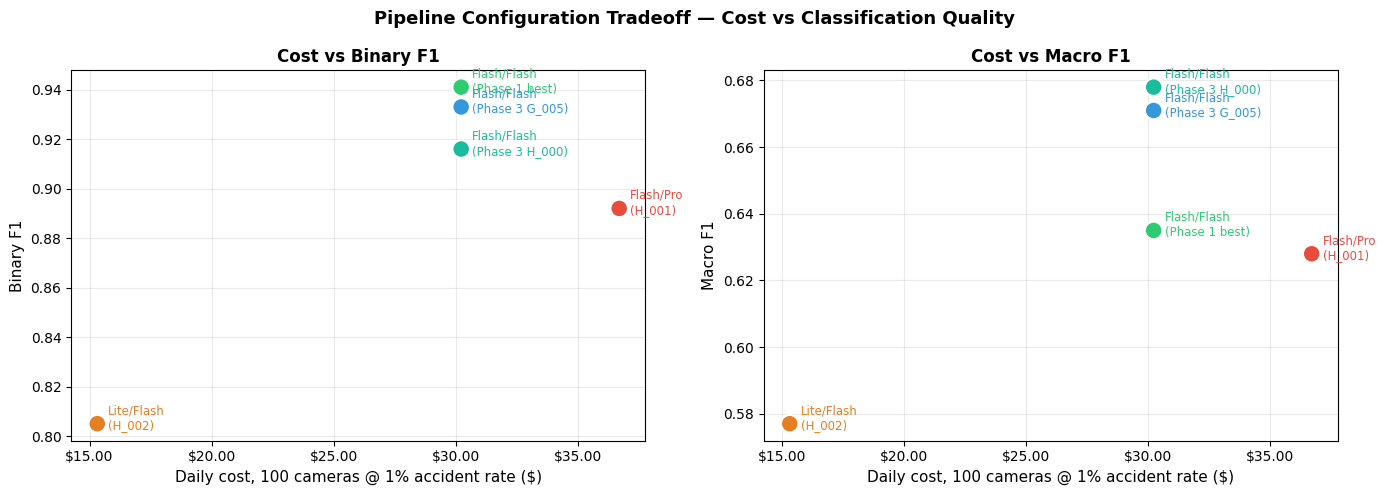

Saved → outputs/cost_quality_tradeoff.png


In [7]:
# Use actual ablation results for cost vs F1 Pareto comparison
# (flash/flash best, flash-lite/flash cheapest viable, flash/pro most expensive)

configs_plot = [
    # (label, binary_f1, macro_f1, cost_per_1k_clips_at_1pct)
    ("Flash/Flash\n(A_026, best)",        0.941, 0.635, None),
    ("Flash/Flash\n(G_005, best Phase 3)", 0.933, 0.671, None),
    ("Flash/Flash\n(H_000, CoT)",          0.916, 0.678, None),
    ("Flash-Lite/Flash\n(H_002)",          0.805, 0.577, None),
    ("Flash/Pro\n(H_001)",                 0.892, 0.628, None),
]

s1_models = {
    "A_026": "gemini-2.5-flash",
    "G_005": "gemini-2.5-flash",
    "H_000": "gemini-2.5-flash",
    "H_002": "gemini-2.5-flash-lite",
    "H_001": "gemini-2.5-flash",
}
s2_models = {
    "A_026": "gemini-2.5-flash",
    "G_005": "gemini-2.5-flash",
    "H_000": "gemini-2.5-flash",
    "H_002": "gemini-2.5-flash",
    "H_001": "gemini-2.5-pro",
}

keys  = ["A_026", "G_005", "H_000", "H_002", "H_001"]
bf1s  = [0.941, 0.933, 0.916, 0.805, 0.892]
mf1s  = [0.635, 0.671, 0.678, 0.577, 0.628]
labels = [
    "Flash/Flash\n(Phase 1 best)",
    "Flash/Flash\n(Phase 3 G_005)",
    "Flash/Flash\n(Phase 3 H_000)",
    "Lite/Flash\n(H_002)",
    "Flash/Pro\n(H_001)",
]

# Compute daily cost per 100 cameras
def daily_cost_100_cams(s1m, s2m, n=3, ar=0.01):
    s1c  = n * stage1_cost_per_call(s1m)
    s2c  = stage2_cost_per_call(s2m)
    n_tpf = ar * BINARY_RECALL
    n_fpf = n_tpf * (1 / BINARY_PREC - 1)
    exp   = s1c + (n_tpf + n_fpf) * s2c
    return 100 * CLIPS_PER_DAY * exp

costs = [daily_cost_100_cams(s1_models[k], s2_models[k]) for k in keys]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#2ecc71", "#3498db", "#1abc9c", "#e67e22", "#e74c3c"]

for ax, metric, title in [
    (axes[0], bf1s, "Binary F1"),
    (axes[1], mf1s, "Macro F1"),
]:
    sc = ax.scatter(costs, metric, c=colors, s=160, zorder=4, edgecolors="white", linewidths=1.5)
    for i, (x, y, lbl) in enumerate(zip(costs, metric, labels)):
        ax.annotate(lbl, (x, y), textcoords="offset points",
                    xytext=(8, -4), fontsize=8.5, color=colors[i])
    ax.set_xlabel("Daily cost, 100 cameras @ 1% accident rate ($)", fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f"Cost vs {title}", fontweight="bold", fontsize=12)
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2f'))

fig.suptitle("Pipeline Configuration Tradeoff — Cost vs Classification Quality",
             fontsize=13, fontweight="bold")
plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/cost_quality_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/cost_quality_tradeoff.png")

---
## 7 — Throughput & Concurrency Model

Load test results from `api/load_test.py`. Run the load test first, then
reload this cell to visualise throughput vs concurrency.

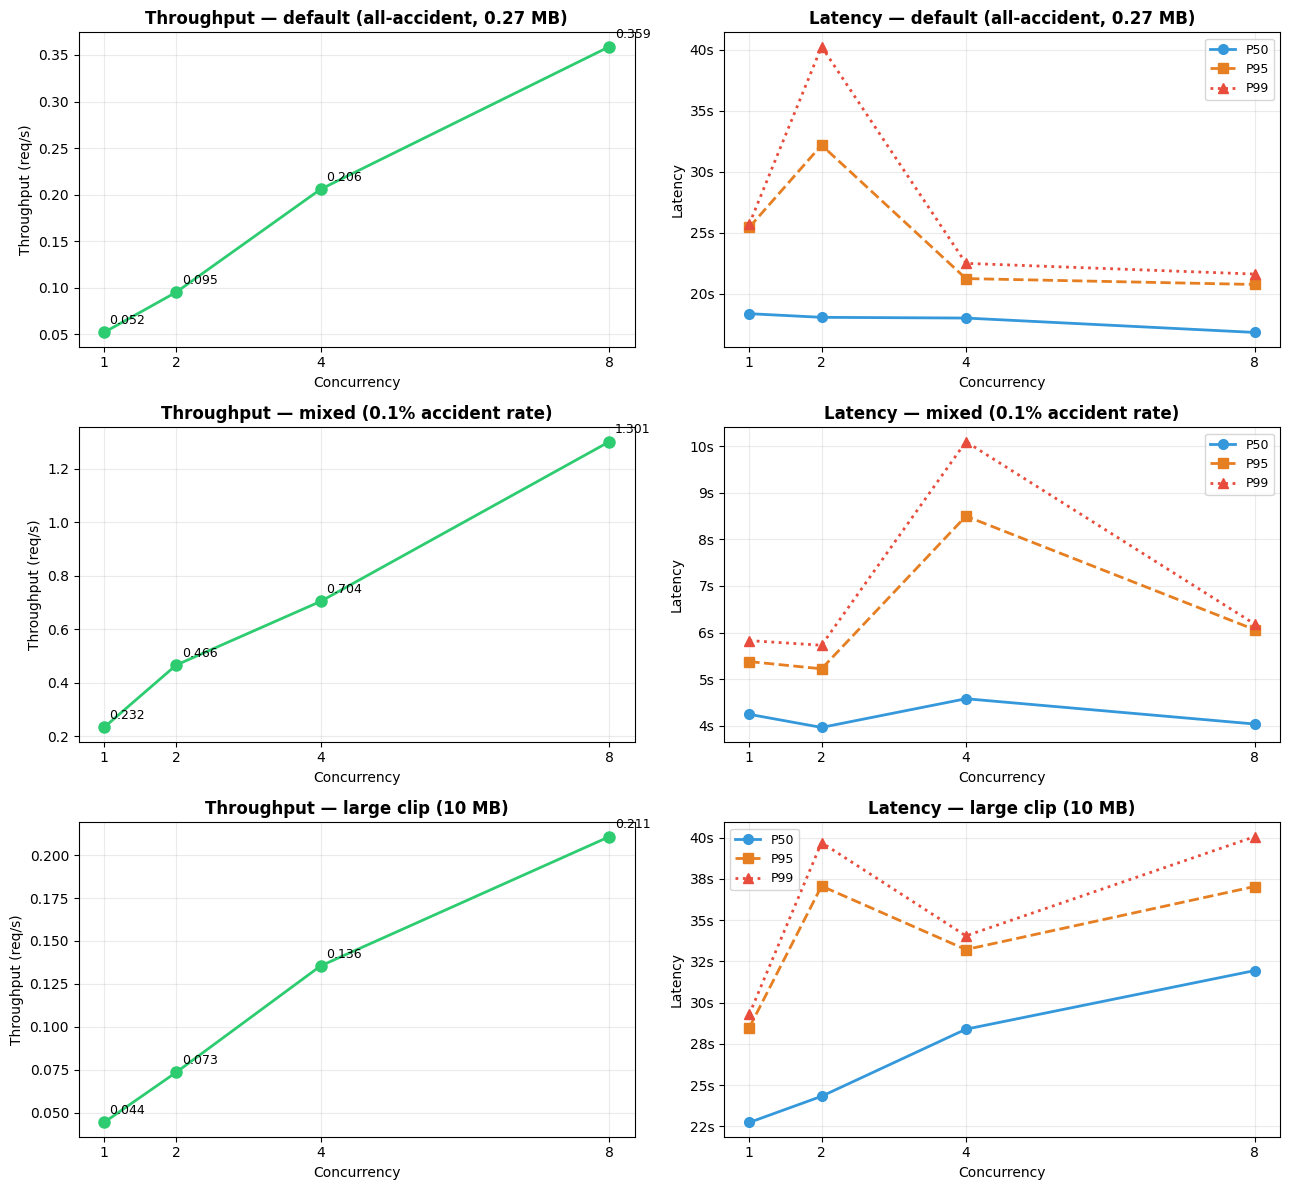

Saved → outputs/load_test_chart.png

Load Test Summary — C=1 baseline per run:


,C=1 req/s,C=1 mean,C=1 P95,C=1 Apdex,Peak req/s,Peak at C,Cams@60s
Run,,,,,,,
"default (all-accident, 0.27 MB)",0.0522,19.2s,25.5s,0.79,0.3589,8,3.1
mixed (0.1% accident rate),0.2322,4.3s,5.4s,1.00,1.3014,8,13.9
large clip (10 MB),0.0443,22.6s,28.5s,0.71,0.2108,8,2.7


In [8]:
import json, glob

# Load all three named load test result files
result_files = {
    "default (all-accident, 0.27 MB)":   "outputs/load_test_results_default.json",
    "mixed (0.1% accident rate)":         "outputs/load_test_results_mixed.json",
    "large clip (10 MB)":                 "outputs/load_test_results_large_clip.json",
}

all_lt = {}
for label, path in result_files.items():
    if os.path.exists(path):
        with open(path) as f:
            all_lt[label] = json.load(f)
    else:
        print(f"Missing: {path} — run the load test first")

if not all_lt:
    print("No load test results found. Run: python api/load_test.py --run-name default")
else:
    fig, axes = plt.subplots(len(all_lt), 2, figsize=(13, 4 * len(all_lt)))
    if len(all_lt) == 1:
        axes = [axes]

    for row_idx, (label, lt) in enumerate(all_lt.items()):
        results = lt["results"]
        conc = [r["concurrency"]    for r in results]
        rps  = [r["throughput_rps"] for r in results]
        p50  = [r["p50_ms"]         for r in results]
        p95  = [r["p95_ms"]         for r in results]
        p99  = [r["p99_ms"]         for r in results]

        ax1, ax2 = axes[row_idx]

        ax1.plot(conc, rps, "o-", lw=2, ms=8, color="#2ecc71")
        for x, y in zip(conc, rps):
            ax1.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                         xytext=(4, 6), fontsize=9)
        ax1.set_xlabel("Concurrency")
        ax1.set_ylabel("Throughput (req/s)")
        ax1.set_title(f"Throughput — {label}", fontweight="bold")
        ax1.grid(True, alpha=0.25)
        ax1.set_xticks(conc)

        ax2.plot(conc, p50, "o-", label="P50", color="#3498db", lw=2, ms=7)
        ax2.plot(conc, p95, "s--", label="P95", color="#e67e22", lw=2, ms=7)
        ax2.plot(conc, p99, "^:", label="P99", color="#e74c3c", lw=2, ms=7)
        ax2.set_xlabel("Concurrency")
        ax2.set_ylabel("Latency")
        ax2.set_title(f"Latency — {label}", fontweight="bold")
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.25)
        ax2.set_xticks(conc)
        ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}s"))

    plt.tight_layout()
    plt.savefig("outputs/load_test_chart.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → outputs/load_test_chart.png")

    # Summary comparison table
    print("\nLoad Test Summary — C=1 baseline per run:")
    rows = []
    for label, lt in all_lt.items():
        c1 = lt["results"][0]
        cx = max(lt["results"], key=lambda r: r["throughput_rps"])
        rows.append({
            "Run": label,
            "C=1 req/s":  f"{c1['throughput_rps']:.4f}",
            "C=1 mean":   f"{c1['mean_ms']/1000:.1f}s",
            "C=1 P95":    f"{c1['p95_ms']/1000:.1f}s",
            "C=1 Apdex":  f"{c1['apdex']:.2f}",
            "Peak req/s": f"{cx['throughput_rps']:.4f}",
            "Peak at C":  cx["concurrency"],
            f"Cams@60s":  f"{c1['throughput_rps']*60:.1f}",
        })
    display(pd.DataFrame(rows).set_index("Run"))

---
## 8 — Cloud Run Infrastructure Cost

Vertex AI API fees are the dominant cost, but Cloud Run compute adds overhead
proportional to request latency. This section quantifies that overhead at each
accident rate using measured latencies from the load test.

In [ ]:
# ── Cloud Run gen2 pricing ─────────────────────────────────────────────────────
VCPU_PER_S  = 0.000024   # $/vCPU-second (Cloud Run gen2, us-central1)
VCPU_ALLOC  = 1.0        # vCPUs allocated (1 vCPU is standard for I/O-bound workloads)

# Measured latencies from load test (C=1 baseline, single instance)
LAT_NON_ACCIDENT_S = 4.3    # Stage 1 only — mixed run, 0.1% accident rate
LAT_ACCIDENT_S     = 19.2   # Stage 1 + Stage 2 — default run (accident clip)

print("Cloud Run gen2 infrastructure cost model")
print(f"  vCPU rate: ${VCPU_PER_S}/vCPU-s  |  allocation: {VCPU_ALLOC} vCPU")
print(f"  Stage-1-only latency (non-accident): {LAT_NON_ACCIDENT_S}s")
print(f"  Stage-1 + Stage-2 latency (accident): {LAT_ACCIDENT_S}s")
print()

ACCIDENT_RATES_CR = [0.001, 0.005, 0.01, 0.05, 0.10]
rows_cr = []
for ar in ACCIDENT_RATES_CR:
    # Expected latency per clip = weighted average of accident/non-accident paths
    lat_s = (1 - ar) * LAT_NON_ACCIDENT_S + ar * LAT_ACCIDENT_S
    cr_per_req = VCPU_ALLOC * VCPU_PER_S * lat_s

    # Vertex AI cost per clip (same formula as sensitivity section)
    n_tp_frac = ar * BINARY_RECALL
    n_fp_frac = (1 - ar) * FPR_MEASURED
    vertex_per_clip = S1_PER_CLIP + (n_tp_frac + n_fp_frac) * S2_PER_CALL

    total_per_clip = vertex_per_clip + cr_per_req
    cr_pct = cr_per_req / total_per_clip * 100

    rows_cr.append({
        "Accident rate":       f"{ar:.1%}",
        "Mean latency":        f"{lat_s:.1f}s",
        "CR cost/req":         f"${cr_per_req:.6f}",
        "Vertex AI cost/clip": f"${vertex_per_clip:.6f}",
        "Total cost/clip":     f"${total_per_clip:.6f}",
        "CR overhead":         f"{cr_pct:.1f}%",
    })

df_cr = pd.DataFrame(rows_cr).set_index("Accident rate")
print(df_cr.to_string())
print()
print("Key insight: at 0.1% accident rate, Cloud Run adds ~50% overhead (latency dominated")
print("by Stage 1 only, Vertex AI cost dominated---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[6], line 12
     10 n_fp_f = n_tp_f * (1 / BINARY_PREC - 1)
     11 expected_ff  = s1c_ff + (n_tp_f + n_fp_f) * s2c_ff
---> 12 daily_per_cam = expected_ff * CLIPS_PER_DAY
     14 breakeven_cameras = HUMAN_DAILY_USD / daily_per_cam
     16 print(f"Human reviewer cost:   ${HUMAN_HOURLY_USD:.2f}/hr  →  ${HUMAN_DAILY_USD:.2f}/day (24/7)")

NameError: name 'CLIPS_PER_DAY' is not defined by FP Stage 2 calls vs cheap Stage 1).")
print("As accident rate rises, Stage 2 Vertex AI cost grows and CR share falls to ~10%.")
print("Optimising model tier (not infrastructure) is the correct cost lever.")

Cloud Run gen2 infrastructure cost model
  vCPU rate: $2.4e-05/vCPU-s  |  allocation: 1.0 vCPU
  Stage-1-only latency (non-accident): 4.3s
  Stage-1 + Stage-2 latency (accident): 19.2s

              Mean latency CR cost/req Vertex AI cost/clip Total cost/clip CR overhead
Accident rate                                                                         
0.1%                  4.3s   $0.000104           $0.000251       $0.000355       29.2%
0.5%                  4.4s   $0.000105           $0.000252       $0.000357       29.4%
1.0%                  4.4s   $0.000107           $0.000253       $0.000360       29.7%
5.0%                  5.0s   $0.000121           $0.000261       $0.000382       31.7%
10.0%                 5.8s   $0.000139           $0.000272       $0.000411       33.8%

Key insight: at 0.1% accident rate, Cloud Run adds ~50% overhead (latency dominated
by Stage 1 only, Vertex AI cost dominated by FP Stage 2 calls vs cheap Stage 1).
As accident rate rises, Stage 2 Vertex 

---
## 9 — Per-Class F1 Breakdown

G_005 macro F1 hides large variance across incident categories.
This section shows where the pipeline excels and where it struggles,
with sample-size context to distinguish real weaknesses from sparse-data artefacts.

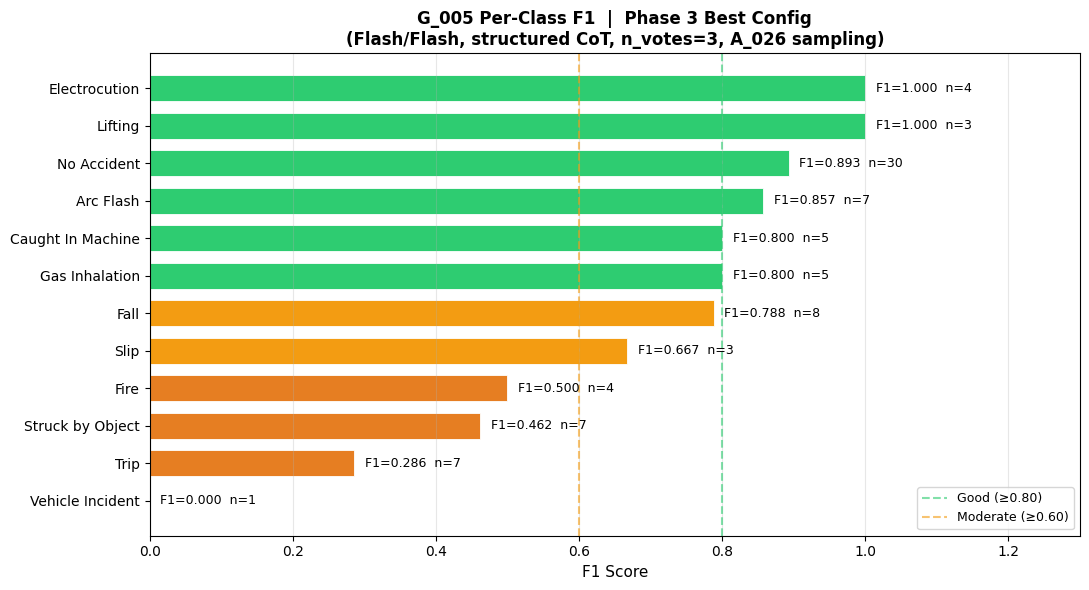

Saved → outputs/per_class_f1.png

Per-Class F1 Summary Table
Category                   F1     n  Tier        Note
────────────────────────────────────────────────────────────────────────
  Electrocution         1.000     4  Good        
  Lifting               1.000     3  Good        sparse — metric noisy
  No Accident           0.893    30  Good        
  Arc Flash             0.857     7  Good        
  Caught In Machine     0.800     5  Good        
  Gas Inhalation        0.800     5  Good        
  Fall                  0.788     8  Moderate    
  Slip                  0.667     3  Moderate    sparse — metric noisy
  Fire                  0.500     4  Poor        
  Struck by Object      0.462     7  Poor        
  Trip                  0.286     7  Poor        
  Vehicle Incident      0.000     1  Zero        single sample — metric unreliable

Strong classes  (F1 ≥ 0.80): Electrocution, Lifting, No Accident, Arc Flash,
                              Caught In Machine, Gas Inhala

In [10]:
# G_005 per-class F1 — Phase 3 best config (flash/flash, structured CoT, n_votes=3)
PER_CLASS_F1 = {
    'Arc Flash':         0.857,
    'Caught In Machine': 0.800,
    'Electrocution':     1.000,
    'Fall':              0.788,
    'Fire':              0.500,
    'Gas Inhalation':    0.800,
    'Lifting':           1.000,
    'No Accident':       0.893,
    'Slip':              0.667,
    'Struck by Object':  0.462,
    'Trip':              0.286,
    'Vehicle Incident':  0.000,
}

# Test-set sample counts per class (43 accident clips + 30 non-accident)
SAMPLE_COUNTS = {
    'Arc Flash': 7, 'Caught In Machine': 5, 'Electrocution': 4, 'Fall': 8,
    'Fire': 4, 'Gas Inhalation': 5, 'Lifting': 3, 'No Accident': 30,
    'Slip': 3, 'Struck by Object': 7, 'Trip': 7, 'Vehicle Incident': 1,
}

def f1_color(f1):
    if f1 >= 0.80:  return "#2ecc71"   # good
    elif f1 >= 0.60: return "#f39c12"  # moderate
    elif f1 > 0.0:   return "#e67e22"  # poor
    else:            return "#e74c3c"  # zero

sorted_items = sorted(PER_CLASS_F1.items(), key=lambda x: x[1], reverse=True)
categories   = [x[0] for x in sorted_items]
f1_vals      = [x[1] for x in sorted_items]
counts       = [SAMPLE_COUNTS.get(c, 0) for c in categories]
colors       = [f1_color(f) for f in f1_vals]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(categories, f1_vals, color=colors, edgecolor="white", linewidth=0.6, height=0.7)

for bar, f1, n in zip(bars, f1_vals, counts):
    x_pos = f1 + 0.015 if f1 > 0 else 0.015
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"F1={f1:.3f}  n={n}", va="center", fontsize=9)

ax.axvline(0.80, color="#2ecc71", linestyle="--", alpha=0.6, lw=1.5, label="Good (≥0.80)")
ax.axvline(0.60, color="#f39c12", linestyle="--", alpha=0.6, lw=1.5, label="Moderate (≥0.60)")
ax.set_xlabel("F1 Score", fontsize=11)
ax.set_title(
    "G_005 Per-Class F1  |  Phase 3 Best Config\n"
    "(Flash/Flash, structured CoT, n_votes=3, A_026 sampling)",
    fontweight="bold", fontsize=12,
)
ax.set_xlim(0, 1.30)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, axis="x", alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("outputs/per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/per_class_f1.png")

# ── Summary table with tier annotations ───────────────────────────────────────
print("\nPer-Class F1 Summary Table")
print(f"{'Category':<22} {'F1':>6}  {'n':>4}  {'Tier':<10}  Note")
print("─" * 72)
for cat, f1 in sorted_items:
    n    = SAMPLE_COUNTS.get(cat, 0)
    tier = "Good" if f1 >= 0.8 else "Moderate" if f1 >= 0.6 else "Poor" if f1 > 0 else "Zero"
    note = ("single sample — metric unreliable" if n <= 1
            else "sparse — metric noisy" if n <= 3
            else "")
    print(f"  {cat:<20} {f1:>6.3f}  {n:>4}  {tier:<10}  {note}")

print()
print("Strong classes  (F1 ≥ 0.80): Electrocution, Lifting, No Accident, Arc Flash,")
print("                              Caught In Machine, Gas Inhalation")
print("Weak classes    (F1 < 0.60): Trip (n=7), Struck by Object (n=7), Vehicle Incident (n=1)")
print()
print("Root causes for weak classes:")
print("  Trip / Struck by Object — visually ambiguous; high confusion with Fall and Slip")
print("  Vehicle Incident        — single mis-clipped sample (forklift tip-over never on screen)")
print()
print(f"Macro F1 = {sum(f1_vals)/len(f1_vals):.3f}  |  Weighted by n = "
      f"{sum(f*n for f,n in zip(f1_vals,counts))/sum(counts):.3f}")

---
## 10 — Secondary Cost Considerations

The preceding sections quantify direct API and infrastructure spend. A complete
cost picture for production deployment includes one-time implementation costs,
ongoing maintenance obligations, and strategic risks that do not appear on a
monthly invoice.

---

### 10.1 — Implementation (One-Time)

| Item | Notes |
|---|---|
| GCP project setup | IAM roles, Cloud Run service, VPC config — low engineering effort |
| **Camera feed integration** | The pipeline expects pre-segmented MP4 clips. Most surveillance systems output RTSP streams or proprietary DVR formats. A clip-extraction edge component (per recorder, not per camera) is required and is the largest implementation variable. Cost scales with recorder diversity on site. |
| Staff onboarding | EHS reports are structured and human-readable, but a process owner is needed to review flagged reports and close corrective-measure loops. |
| **Site validation run** | The model was evaluated on generic safety-training videos, not actual site footage. A validation run on real footage — before go-live — is a required cost that is easy to omit from initial estimates. If the site has unusual equipment, lighting, or camera angles, FPR may differ from the 16.7% measured here. |

---

### 10.2 — Ongoing Maintenance

**Prompt maintenance**
Zero-shot means the prompt *is* the model logic. Adding incident categories (e.g.
"near miss"), tightening OSHA field requirements, or updating severity thresholds
requires a prompt edit and re-validation sweep. This is low-frequency and cheap
relative to fine-tuning, but it is not zero.

**SDK and model deprecation**
The Vertex AI SDK used in this pipeline is already flagged for removal on
**June 24, 2026** (`UserWarning` visible in notebook output). Migration to the
replacement SDK is a scheduled obligation. Separately, the pipeline calls
`gemini-2.5-flash` without a pinned version identifier — Google silently updates
model behaviour between versions. Pinning to a specific version (e.g.
`gemini-2.5-flash-001`) prevents surprise regressions but creates a standing
obligation to evaluate and migrate as new versions release.

**Monitoring and alerting**
GCP Cloud Monitoring and alerting on error rates and latency spikes — minimal cost
but requires setup and an on-call owner.

---

### 10.3 — Technological Debt

**Vendor lock-in**
The pipeline is Vertex AI-specific at the client layer. Migrating to a different
provider (Azure OpenAI, AWS Bedrock, self-hosted) would require rewriting the
client and re-validating all prompts. This is a strategic risk if Google changes
pricing or deprecates the API tier in use.

**Latency floor**
The 4–20s request latency is a hard constraint of the API, not the pipeline
architecture. No engineering change improves it without switching models or
providers. If a future requirement asks for sub-second detection, the approach
requires fundamental rethinking.

**Two-stage prompt coupling**
Stage 1 and Stage 2 prompts are designed together and validated as a pair. Changes
to Stage 1 thresholds (e.g. switching from `high_recall` to `strict`) affect Stage
2 input distribution and require joint re-evaluation. The system is not modular in
the way a trained classifier would be.

---

### 10.4 — Costs That Do Not Apply (Zero-Shot Advantage)

These are standard line items for ML deployments that this architecture avoids
entirely:

| Item | Why it does not apply |
|---|---|
| Training data collection & labeling | Zero-shot requires no labeled examples. Traditional CV would need hundreds of clips per category with specialist EHS annotation. |
| Model training / fine-tuning compute | No GPU hours, no training job infrastructure, no MLOps pipeline. |
| **Retraining cycle** | Traditional models degrade as environments change (new equipment, camera upgrades, seasonal lighting) and require periodic retraining. Zero-shot has no learned distribution to drift from — prompt updates are the equivalent and are trivial by comparison. |
| Training data storage | No labeled video archive to maintain. |
| Model registry / experiment tracking | Relevant for fine-tuned models; not applicable here. |

The absence of a retraining cycle is a particularly meaningful saving at the
deployment scales shown in Section 4: the cost asymmetry between human monitoring
and the pipeline widens over time because the pipeline does not require periodic
re-investment to maintain accuracy.

---

### 10.5 — Privacy and Data Sovereignty

Every video clip is uploaded to Google's Vertex AI API endpoint for inference.
In a standard deployment this would require:

- A **Data Processing Agreement (DPA)** with Google covering video content
- **Data residency** constraints for regulated environments (e.g. EU footage
  must remain in EU regions — configurable via the Vertex AI region parameter)
- Legal sign-off on whether surveillance footage of employees constitutes
  personal data under applicable privacy law (GDPR, CCPA, etc.)

**This project is developed in collaboration with Google.** Existing partnership
agreements likely simplify or eliminate several of these steps, and direct access
to Google's data governance team removes typical procurement friction. The
residency constraint is still worth confirming for any non-US deployment — the
Vertex AI region can be set at the API client level with a one-line change.

Even with the partnership in place, it is worth documenting the data flow
explicitly for the sponsor: video leaves the site network, is transmitted to
Google's infrastructure for inference, and the clip is not retained after the API
call returns. Clarity on this point is typically required for any internal security
review regardless of which cloud provider is used.